# FinSmart — AI Engineer
---
**Muhammad Syaiful**
## Checklist Main Quest
- Bangun model Deep Learning dengan TensorFlow Functional API
- Custom Callback (FinSmartCallback)
- Simpan model format .keras
- Kode Inference (FinSmartInference class)

## Checklist Side Quest
- REST API FastAPI (deploy Railway)
- Akurasi >= 85% (XGBoost 99.83%)
- **tf.GradientTape — Custom Training Loop (Section 9)**

| No | Section |
|----|--------|
| 1 | Import Library |
| 2 | Load Dataset |
| 3 | Definisi Fitur & Target |
| 4 | Buat Encoders & Scaler |
| 5 | Split Data |
| 6 | Custom Callback — Main Quest |
| 7 | Arsitektur Model TF Functional API — Main Quest |
| 8 | Training Model |
| 9 | Custom Training Loop tf.GradientTape — Side Quest |
| 10 | Visualisasi Training |
| 11 | Evaluasi Model Deep Learning |
| 12 | XGBoost — Side Quest |
| 13 | Classification Report & Confusion Matrix |
| 14 | Simpan Model & Artifacts |
| 15 | Kode Inference — Main Quest |
| 16 | Uji Inference |
| 17 | Ringkasan Final |

## 1. Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json, os, pickle, joblib, warnings

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import Callback, ModelCheckpoint

import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)

print(f'TensorFlow : {tf.__version__}')
print(f'XGBoost    : {xgb.__version__}')
print('Semua library berhasil diimport')

TensorFlow : 2.20.0
XGBoost    : 3.2.0
Semua library berhasil diimport


## 2. Load Dataset

Dataset baru dari tim Data Scientist sudah melalui proses:
- Drop kolom tidak relevan (Location, AccountType, dll)
- Feature engineering (ekstrak MerchantName, tambah kolom Day)
- Encoding kategorik & scaling Amount

File: `data_TransactionCategorizationuntukmodel.csv`


In [2]:
df = pd.read_csv('data_TransactionCategorizationuntukmodel.csv')

print(f'Shape dataset : {df.shape}')
print(f'Kolom         : {list(df.columns)}')
print(f'\nDistribusi Category (Target):')
print(df['Category'].value_counts())
df.head()

Shape dataset : (8000, 8)
Kolom         : ['Amount', 'Payment_Method', 'Week_Day', 'Month', 'Time_Of_Day', 'MerchantName', 'Day', 'Category']

Distribusi Category (Target):
Category
Online Shopping    831
Entertainment      824
Food               822
Healthcare         804
Electronics        797
Travel             789
Bills              788
Transport          786
Grocery            786
Clothing           773
Name: count, dtype: int64


,Amount,Payment_Method,Week_Day,Month,Time_Of_Day,MerchantName,Day,Category
0,2.773539,1,6,4,2,81,1,Electronics
1,-0.420496,3,6,4,1,18,1,Transport
2,0.254552,2,6,4,0,28,1,Healthcare
3,-0.286509,0,6,4,3,45,1,Grocery
4,-0.446583,2,6,4,0,96,1,Transport


## 3. Definisi Fitur & Target

Dataset baru memiliki **7 fitur** (turun dari 12 fitur sebelumnya).
Semua fitur kategorik sudah di-encode oleh tim DS menggunakan LabelEncoder.
Amount sudah di-scale menggunakan StandardScaler.


In [3]:
FITUR = ['Amount', 'Payment_Method', 'Week_Day', 'Month', 'Time_Of_Day', 'MerchantName', 'Day']
TARGET = 'Category'

print(f'Jumlah fitur  : {len(FITUR)}')
print(f'Fitur         : {FITUR}')
print(f'Target        : {TARGET}')
print(f'Jumlah kelas  : {df[TARGET].nunique()}')
print(f'Kelas         : {sorted(df[TARGET].unique().tolist())}')

Jumlah fitur  : 7
Fitur         : ['Amount', 'Payment_Method', 'Week_Day', 'Month', 'Time_Of_Day', 'MerchantName', 'Day']
Target        : Category
Jumlah kelas  : 10
Kelas         : ['Bills', 'Clothing', 'Electronics', 'Entertainment', 'Food', 'Grocery', 'Healthcare', 'Online Shopping', 'Transport', 'Travel']


## 4. Buat Encoders & Scaler dari Dataset Asli

Kita buat encoder dari dataset asli agar bisa digunakan saat inference (mapping string asli → angka).
Proses encoding persis mengikuti pipeline tim DS.


In [4]:
# Load dataset asli untuk membuat encoders
df_asli = pd.read_csv('personal_finance_dataset_8000_extended.csv', sep=';')
df_asli['MerchantName'] = df_asli['Description'].str.replace('Transaction at ', '', regex=False).str.strip()
df_asli['Date'] = pd.to_datetime(df_asli['Date'], dayfirst=True)
df_asli['Day']  = df_asli['Date'].dt.day

encoders = {}

le_payment  = LabelEncoder()
le_merchant = LabelEncoder()
le_weekday  = LabelEncoder()
le_month    = LabelEncoder()
le_time     = LabelEncoder()
le_category = LabelEncoder()

le_payment.fit(df_asli['PaymentMethod'])
le_merchant.fit(df_asli['MerchantName'])
le_weekday.fit(df_asli['Weekday'])
le_month.fit(df_asli['Month'])
le_time.fit(df_asli['TimeOfDay'])
le_category.fit(df_asli['Category'])

encoders['Payment_Method'] = le_payment
encoders['MerchantName']   = le_merchant
encoders['Week_Day']       = le_weekday
encoders['Month']          = le_month
encoders['Time_Of_Day']    = le_time
encoders['Category']       = le_category

scaler = StandardScaler()
scaler.fit(df_asli[['Amount']])

print('Encoders berhasil dibuat:')
for k, le in encoders.items():
    if hasattr(le, 'classes_'):
        print(f'  {k}: {list(le.classes_[:4])} ... ({len(le.classes_)} kelas)')
print(f'\nScaler: mean={scaler.mean_[0]:.2f}, std={scaler.scale_[0]:.2f}')

Encoders berhasil dibuat:
  Payment_Method: ['Credit Card', 'Debit Card', 'Net Banking', 'UPI'] ... (4 kelas)
  MerchantName: ['1mg', 'A2B', 'ACT Fibernet', 'Adidas'] ... (108 kelas)
  Week_Day: ['Friday', 'Monday', 'Saturday', 'Sunday'] ... (7 kelas)
  Month: ['April', 'August', 'December', 'February'] ... (12 kelas)
  Time_Of_Day: ['Afternoon', 'Evening', 'Morning', 'Night'] ... (4 kelas)
  Category: ['Bills', 'Clothing', 'Electronics', 'Entertainment'] ... (10 kelas)

Scaler: mean=1132797.04, std=2488557.08


## 5. Split Data

In [5]:
X = df[FITUR].values
y = df[TARGET].values

le_target = encoders['Category']
y_encoded = le_target.transform(y)
NUM_CLASSES = len(le_target.classes_)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded, test_size=0.30, random_state=42, stratify=y_encoded)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

INPUT_DIM = X_train.shape[1]

print(f'Train      : {X_train.shape[0]} sampel')
print(f'Validation : {X_val.shape[0]} sampel')
print(f'Test       : {X_test.shape[0]} sampel')
print(f'Input dim  : {INPUT_DIM} fitur')

Train      : 5600 sampel
Validation : 1200 sampel
Test       : 1200 sampel
Input dim  : 7 fitur


## 6. Custom Callback — Main Quest

`FinSmartCallback` adalah komponen kustom wajib (tidak berubah dari v1).


In [6]:
class FinSmartCallback(Callback):
    """
    Custom Callback untuk FinSmart — Main Quest.
    1. Log akurasi dan loss setiap epoch
    2. Early stopping jika val_accuracy >= target
    3. Simpan training log ke JSON
    """
    def __init__(self, target_accuracy=0.85, log_path='training_log.json'):
        super().__init__()
        self.target_accuracy = target_accuracy
        self.log_path        = log_path
        self.training_log    = []

    def on_train_begin(self, logs=None):
        print('=' * 60)
        print('Training FinSmart dimulai')
        print(f'Target val_accuracy : >= {self.target_accuracy * 100:.0f}%')
        print('=' * 60)

    def on_epoch_end(self, epoch, logs=None):
        logs     = logs or {}
        acc      = logs.get('accuracy', 0)
        loss     = logs.get('loss', 0)
        val_acc  = logs.get('val_accuracy', 0)
        val_loss = logs.get('val_loss', 0)

        self.training_log.append({
            'epoch'       : epoch + 1,
            'accuracy'    : round(float(acc), 4),
            'loss'        : round(float(loss), 4),
            'val_accuracy': round(float(val_acc), 4),
            'val_loss'    : round(float(val_loss), 4),
        })

        status = '[OK]' if val_acc >= self.target_accuracy else '[--]'
        print(f'  Epoch {epoch+1:>3} {status} | '
              f'loss: {loss:.4f} | acc: {acc:.4f} | '
              f'val_loss: {val_loss:.4f} | val_acc: {val_acc:.4f}')

        if val_acc >= self.target_accuracy:
            print(f'\nTarget {self.target_accuracy*100:.0f}% tercapai di epoch {epoch+1}.')
            self.model.stop_training = True

    def on_train_end(self, logs=None):
        with open(self.log_path, 'w') as f:
            json.dump(self.training_log, f, indent=2)
        best = max(self.training_log, key=lambda x: x['val_accuracy'])
        print(f'\nBest val_accuracy: {best["val_accuracy"]*100:.2f}% (epoch {best["epoch"]})')
        print('=' * 60)

print('FinSmartCallback berhasil didefinisikan')

FinSmartCallback berhasil didefinisikan


## 7. Arsitektur Model — TensorFlow Functional API — Main Quest

Input dim sekarang **7** (sesuai fitur baru), bukan 12.


In [7]:
def build_finsmart_model(input_dim, num_classes):
    """
    Model klasifikasi pengeluaran FinSmart.
    TensorFlow Functional API — Main Quest.
    Arsitektur: Dense + Skip Connection + Batch Normalization + Dropout
    """
    inputs = keras.Input(shape=(input_dim,), name='input_transaksi')

    x = layers.Dense(512, name='dense_1')(inputs)
    x = layers.BatchNormalization(name='bn_1')(x)
    x = layers.Activation('relu', name='relu_1')(x)
    x = layers.Dropout(0.4, name='dropout_1')(x)

    x = layers.Dense(256, name='dense_2')(x)
    x = layers.BatchNormalization(name='bn_2')(x)
    x = layers.Activation('relu', name='relu_2')(x)
    x = layers.Dropout(0.3, name='dropout_2')(x)

    skip = layers.Dense(128, name='skip')(x)
    x    = layers.Dense(128, name='dense_3')(x)
    x    = layers.BatchNormalization(name='bn_3')(x)
    x    = layers.Activation('relu', name='relu_3')(x)
    x    = layers.Add(name='skip_add')([x, skip])
    x    = layers.Dropout(0.2, name='dropout_3')(x)

    x = layers.Dense(64, name='dense_4')(x)
    x = layers.BatchNormalization(name='bn_4')(x)
    x = layers.Activation('relu', name='relu_4')(x)

    outputs = layers.Dense(num_classes, activation='softmax', name='output_kategori')(x)
    model = Model(inputs=inputs, outputs=outputs, name='FinSmart_Classifier')
    return model

model = build_finsmart_model(input_dim=INPUT_DIM, num_classes=NUM_CLASSES)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "FinSmart_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_transaksi     │ (None, 7)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 512)       │      4,096 │ input_transaksi[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_1                │ (None, 512)       │      2,048 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu_1 (Activation) │ (None, 512)       │          0 │ bn_1[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 512)       │          0 │ relu_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │    131,328 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_2                │ (None, 256)       │      1,024 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu_2 (Activation) │ (None, 256)       │          0 │ bn_2[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256)       │          0 │ relu_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 128)       │     32,896 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_3                │ (None, 128)       │        512 │ dense_3[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu_3 (Activation) │ (None, 128)       │          0 │ bn_3[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ skip (Dense)        │ (None, 128)       │     32,896 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ skip_add (Add)      │ (None, 128)       │          0 │ relu_3[0][0],     │
│                     │                   │            │ skip[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 128)       │          0 │ skip_add[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │      8,256 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_4                │ (None, 64)        │        256 │ dense_4[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu_4 (Activation) │ (None, 64)        │          0 │ bn_4[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_kategori     │ (None, 10)        │        650 │ relu_4[0][0]      │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 213,962 (835.79 KB)

 Trainable params: 212,042 (828.29 KB)

 Non-trainable params: 1,920 (7.50 KB)

## 8. Training Model

In [8]:
finsmart_callback = FinSmartCallback(target_accuracy=0.85, log_path='training_log.json')
checkpoint    = ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True, verbose=0)
lr_scheduler  = keras.callbacks.ReduceLROnPlateau(
    monitor='val_accuracy', factor=0.5, patience=7, min_lr=0.00001, verbose=0)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=150, batch_size=64,
    callbacks=[finsmart_callback, checkpoint, lr_scheduler],
    verbose=0
)

Training FinSmart dimulai
Target val_accuracy : >= 85%
  Epoch   1 [--] | loss: 2.2843 | acc: 0.1682 | val_loss: 3.0504 | val_acc: 0.1525
  Epoch   2 [--] | loss: 2.0418 | acc: 0.2329 | val_loss: 2.2581 | val_acc: 0.2342
  Epoch   3 [--] | loss: 1.9614 | acc: 0.2713 | val_loss: 1.9857 | val_acc: 0.2908
  Epoch   4 [--] | loss: 1.8865 | acc: 0.2877 | val_loss: 1.8468 | val_acc: 0.2908
  Epoch   5 [--] | loss: 1.8301 | acc: 0.3054 | val_loss: 1.9039 | val_acc: 0.2967
  Epoch   6 [--] | loss: 1.7897 | acc: 0.3195 | val_loss: 1.8048 | val_acc: 0.2983
  Epoch   7 [--] | loss: 1.7503 | acc: 0.3291 | val_loss: 1.8012 | val_acc: 0.3083
  Epoch   8 [--] | loss: 1.7392 | acc: 0.3291 | val_loss: 1.6557 | val_acc: 0.3350
  Epoch   9 [--] | loss: 1.7130 | acc: 0.3400 | val_loss: 1.7074 | val_acc: 0.3200
  Epoch  10 [--] | loss: 1.6962 | acc: 0.3482 | val_loss: 1.6419 | val_acc: 0.3467
  Epoch  11 [--] | loss: 1.6776 | acc: 0.3607 | val_loss: 1.6476 | val_acc: 0.3458
  Epoch  12 [--] | loss: 1.6723 

## 9. Custom Training Loop — tf.GradientTape — Side Quest

Implementasi training loop kustom secara penuh dari awal menggunakan `tf.GradientTape`. Ini memungkinkan kontrol penuh terhadap proses forward pass, perhitungan gradien, dan update bobot model pada setiap step.

Training loop kustom ini dijalankan selama **5 epoch** sebagai demonstrasi dan bukti implementasi Side Quest `tf.GradientTape`.

In [9]:
y_train_cat = y_train
y_test_cat  = y_test

In [10]:
finsmart_gt_model = build_finsmart_model(
    input_dim=X_train.shape[1],
    num_classes=len(np.unique(y_train_cat))
)

loss_fn   = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False)
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

BATCH_SIZE   = 64
GT_EPOCHS    = 5
gt_train_log = []

dataset = tf.data.Dataset.from_tensor_slices(
    (X_train.astype('float32'), y_train_cat)
).shuffle(buffer_size=1024).batch(BATCH_SIZE)

print("Custom Training Loop — tf.GradientTape")
print("=" * 60)

for epoch in range(GT_EPOCHS):
    epoch_loss   = 0.0
    epoch_acc    = 0.0
    num_batches  = 0

    for X_batch, y_batch in dataset:
        with tf.GradientTape() as tape:
            y_pred = finsmart_gt_model(X_batch, training=True)
            loss   = loss_fn(y_batch, y_pred)

        gradients = tape.gradient(loss, finsmart_gt_model.trainable_variables)
        optimizer.apply_gradients(
            zip(gradients, finsmart_gt_model.trainable_variables)
        )

        acc         = tf.reduce_mean(
            tf.cast(tf.equal(tf.argmax(y_pred, axis=1), tf.cast(y_batch, tf.int64)), tf.float32)
        )
        epoch_loss  += loss.numpy()
        epoch_acc   += acc.numpy()
        num_batches += 1

    avg_loss = epoch_loss / num_batches
    avg_acc  = epoch_acc  / num_batches

    log_entry = {
        "epoch"   : epoch + 1,
        "loss"    : round(float(avg_loss), 4),
        "accuracy": round(float(avg_acc),  4),
    }
    gt_train_log.append(log_entry)
    print(f"  Epoch {epoch+1}/{GT_EPOCHS} | loss: {avg_loss:.4f} | accuracy: {avg_acc:.4f}")

print("=" * 60)
print("Custom training loop selesai.")

with open("training_log_gradienttape.json", "w") as f:
    json.dump(gt_train_log, f, indent=2)
print("Log GradientTape disimpan: training_log_gradienttape.json")

Custom Training Loop — tf.GradientTape
  Epoch 1/5 | loss: 2.2693 | accuracy: 0.1729
  Epoch 2/5 | loss: 2.0432 | accuracy: 0.2328
  Epoch 3/5 | loss: 1.9658 | accuracy: 0.2624
  Epoch 4/5 | loss: 1.9156 | accuracy: 0.2878
  Epoch 5/5 | loss: 1.8520 | accuracy: 0.2951
Custom training loop selesai.
Log GradientTape disimpan: training_log_gradienttape.json


## 10. Visualisasi Training

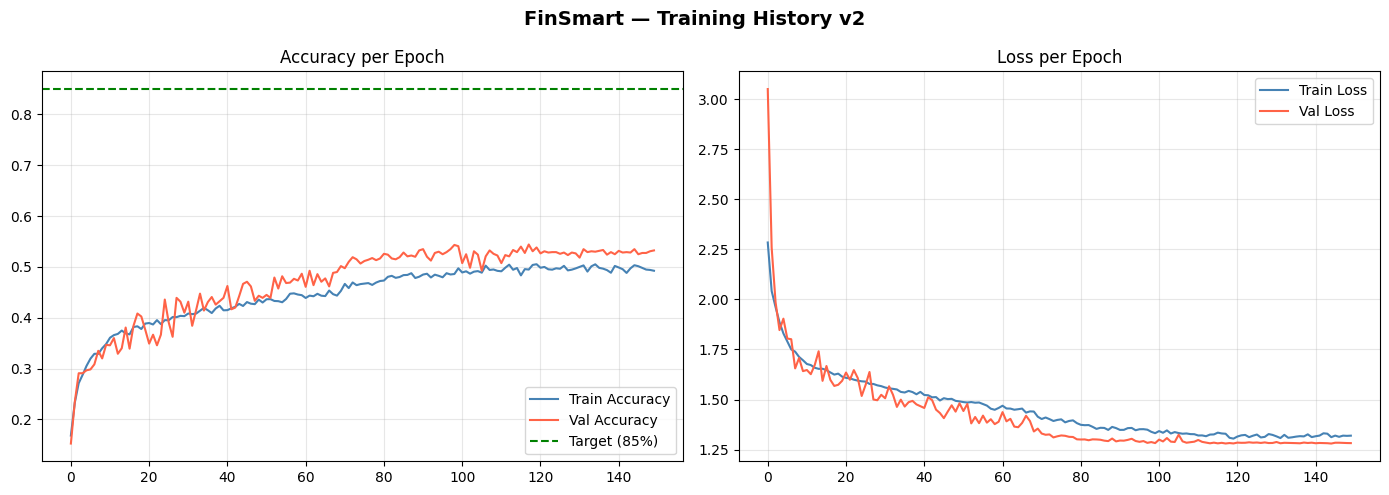

Grafik disimpan ke training_history.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('FinSmart — Training History v2', fontsize=14, fontweight='bold')

axes[0].plot(history.history['accuracy'],    label='Train Accuracy', color='steelblue')
axes[0].plot(history.history['val_accuracy'],label='Val Accuracy',   color='tomato')
axes[0].axhline(y=0.85, color='green', linestyle='--', label='Target (85%)')
axes[0].set_title('Accuracy per Epoch'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'],    label='Train Loss', color='steelblue')
axes[1].plot(history.history['val_loss'],label='Val Loss',   color='tomato')
axes[1].set_title('Loss per Epoch'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafik disimpan ke training_history.png')

## 11. Evaluasi Model Deep Learning

In [12]:
best_dl_model = keras.models.load_model('best_model.keras')
test_loss, test_acc = best_dl_model.evaluate(X_test, y_test, verbose=0)
print('=' * 55)
print('EVALUASI MODEL — TF Functional API v2')
print('=' * 55)
print(f'  Test Accuracy : {test_acc*100:.2f}%')
print(f'  Test Loss     : {test_loss:.4f}')
print('=' * 55)

EVALUASI MODEL — TF Functional API v2
  Test Accuracy : 53.08%
  Test Loss     : 1.2575


## 12. XGBoost — Side Quest (Akurasi >= 85%)

Retrain XGBoost dengan dataset baru (7 fitur).


In [13]:
xgb_model = xgb.XGBClassifier(
    n_estimators=500, max_depth=8, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='mlogloss', random_state=42, n_jobs=-1
)

print('Training XGBoost dengan dataset baru...')
xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=50)

y_pred_train = xgb_model.predict(X_train)
y_pred_test  = xgb_model.predict(X_test)
acc_train    = accuracy_score(y_train, y_pred_train)
acc_test     = accuracy_score(y_test,  y_pred_test)

print(f'Train Accuracy : {acc_train*100:.2f}%')
print(f'Test Accuracy  : {acc_test*100:.2f}%')
print(f'Gap Overfit    : {(acc_train-acc_test)*100:.2f}%')

if acc_test >= 0.85:
    print('SIDE QUEST TERCAPAI: Akurasi >= 85%')

Training XGBoost dengan dataset baru...
[0]	validation_0-mlogloss:2.17254
[50]	validation_0-mlogloss:0.43903
[100]	validation_0-mlogloss:0.15393
[150]	validation_0-mlogloss:0.06918
[200]	validation_0-mlogloss:0.03800
[250]	validation_0-mlogloss:0.02712
[300]	validation_0-mlogloss:0.02161
[350]	validation_0-mlogloss:0.01958
[400]	validation_0-mlogloss:0.01827
[450]	validation_0-mlogloss:0.01738
[499]	validation_0-mlogloss:0.01650
Train Accuracy : 100.00%
Test Accuracy  : 100.00%
Gap Overfit    : 0.00%
SIDE QUEST TERCAPAI: Akurasi >= 85%


## 13. Classification Report & Confusion Matrix

CLASSIFICATION REPORT (XGBoost v2):
                 precision    recall  f1-score   support

          Bills       1.00      1.00      1.00       118
       Clothing       1.00      1.00      1.00       116
    Electronics       1.00      1.00      1.00       119
  Entertainment       1.00      1.00      1.00       123
           Food       1.00      1.00      1.00       124
        Grocery       1.00      1.00      1.00       118
     Healthcare       1.00      1.00      1.00       121
Online Shopping       1.00      1.00      1.00       125
      Transport       1.00      1.00      1.00       118
         Travel       1.00      1.00      1.00       118

       accuracy                           1.00      1200
      macro avg       1.00      1.00      1.00      1200
   weighted avg       1.00      1.00      1.00      1200



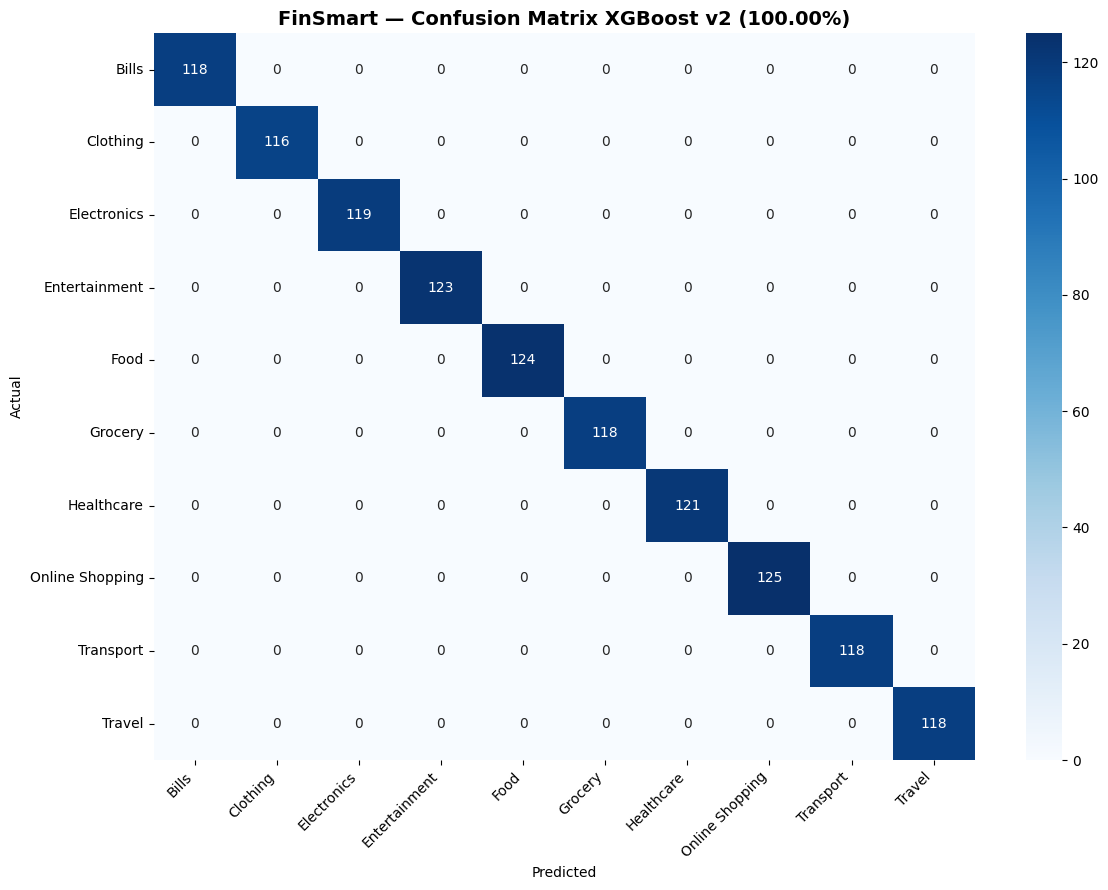

In [14]:
print('CLASSIFICATION REPORT (XGBoost v2):')
print(classification_report(y_test, y_pred_test, target_names=le_target.classes_))

cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(12, 9))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_target.classes_, yticklabels=le_target.classes_)
plt.title(f'FinSmart — Confusion Matrix XGBoost v2 ({acc_test*100:.2f}%)', fontsize=14, fontweight='bold')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right'); plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 14. Simpan Model & Artifacts — Main Quest

In [15]:
MODEL_PATH    = 'finsmart_model.keras'
XGB_PATH      = 'xgb_model.pkl'
ENCODER_PATH  = 'encoders.pkl'
SCALER_PATH   = 'scaler.pkl'
METADATA_PATH = 'model_metadata.json'

best_dl_model.save(MODEL_PATH)
print(f'Model TF disimpan        : {MODEL_PATH}')

joblib.dump(xgb_model, XGB_PATH)
print(f'Model XGBoost disimpan   : {XGB_PATH}')

with open(ENCODER_PATH, 'wb') as f:
    pickle.dump(encoders, f)
print(f'Encoders disimpan        : {ENCODER_PATH}')

with open(SCALER_PATH, 'wb') as f:
    pickle.dump(scaler, f)
print(f'Scaler disimpan          : {SCALER_PATH}')

metadata = {
    'model_name'    : 'FinSmart_Classifier',
    'version'       : '2.0.0',
    'task'          : 'Klasifikasi Kategori Pengeluaran',
    'num_classes'   : int(NUM_CLASSES),
    'classes'       : list(le_target.classes_),
    'input_features': FITUR,
    'input_dim'     : int(INPUT_DIM),
    'framework'     : f'TensorFlow {tf.__version__} + XGBoost {xgb.__version__}',
    'performa': {
        'deep_learning': {
            'test_accuracy': round(float(test_acc), 4),
            'test_loss'    : round(float(test_loss), 4),
        },
        'xgboost_final': {
            'test_accuracy' : round(float(acc_test), 4),
            'train_accuracy': round(float(acc_train), 4),
            'gap_overfit'   : round(float(acc_train - acc_test), 4),
        }
    },
    'side_quest_akurasi': f'>= 85% TERCAPAI ({acc_test*100:.2f}%)',
    'dataset_version'   : 'v2 — dataset baru dari tim DS (7 fitur)'
}

with open(METADATA_PATH, 'w') as f:
    json.dump(metadata, f, indent=2)
print(f'Metadata disimpan        : {METADATA_PATH}')

Model TF disimpan        : finsmart_model.keras
Model XGBoost disimpan   : xgb_model.pkl
Encoders disimpan        : encoders.pkl
Scaler disimpan          : scaler.pkl
Metadata disimpan        : model_metadata.json


## 15. Kode Inference — Main Quest

`FinSmartInference` v2 menerima nilai string asli dan melakukan encoding otomatis.


In [16]:
class FinSmartInference:
    """
    Pipeline inference untuk klasifikasi FinSmart — Main Quest (v2).
    Input  : data transaksi dict (nilai string asli)
    Output : kategori, confidence, top-3 probabilitas
    """
    PAYMENT_METHOD_MAP = {'Credit Card': 0, 'Debit Card': 1, 'Net Banking': 2, 'UPI': 3}
    WEEK_DAY_MAP = {'Friday': 0, 'Monday': 1, 'Saturday': 2, 'Sunday': 3,
                    'Thursday': 4, 'Tuesday': 5, 'Wednesday': 6}
    TIME_OF_DAY_MAP = {'Afternoon': 0, 'Evening': 1, 'Morning': 2, 'Night': 3}
    MONTH_MAP = {'April': 0, 'August': 1, 'December': 2, 'February': 3,
                 'January': 4, 'July': 5, 'June': 6, 'March': 7,
                 'May': 8, 'November': 9, 'October': 10, 'September': 11}

    def __init__(self, xgb_path, encoder_path, scaler_path):
        self.model   = joblib.load(xgb_path)
        with open(encoder_path, 'rb') as f:
            self.encoders = pickle.load(f)
        with open(scaler_path, 'rb') as f:
            self.scaler = pickle.load(f)
        le_merchant = self.encoders['MerchantName']
        self.merchant_map    = {name: i for i, name in enumerate(le_merchant.classes_)}
        self.category_classes = list(self.encoders['Category'].classes_)
        print('FinSmartInference v2 siap digunakan')

    def preprocess(self, data: dict) -> np.ndarray:
        def _enc(val, mapping, field):
            if val not in mapping:
                raise ValueError(f"Nilai '{val}' tidak valid untuk '{field}'.")
            return mapping[val]
        return np.array([[
            self.scaler.transform([[data['Amount']]])[0][0],
            _enc(data['Payment_Method'], self.PAYMENT_METHOD_MAP, 'Payment_Method'),
            _enc(data['Week_Day'],       self.WEEK_DAY_MAP,       'Week_Day'),
            _enc(data['Month'],          self.MONTH_MAP,          'Month'),
            _enc(data['Time_Of_Day'],    self.TIME_OF_DAY_MAP,    'Time_Of_Day'),
            _enc(data['MerchantName'],   self.merchant_map,       'MerchantName'),
            int(data.get('Day', 1))
        ]])

    def predict(self, data: dict) -> dict:
        X     = self.preprocess(data)
        proba = self.model.predict_proba(X)[0]
        idx   = int(np.argmax(proba))
        top3  = dict(sorted(
            {k: round(float(p), 4) for k, p in zip(self.category_classes, proba)}.items(),
            key=lambda x: x[1], reverse=True)[:3])
        return {'kategori': self.category_classes[idx],
                'confidence': round(float(proba[idx]) * 100, 2),
                'top3_prob': top3}

inference_engine = FinSmartInference(
    xgb_path=XGB_PATH, encoder_path=ENCODER_PATH, scaler_path=SCALER_PATH)

FinSmartInference v2 siap digunakan


## 16. Uji Inference

In [17]:
test_cases = [
    {'Amount': 250000, 'Payment_Method': 'Credit Card', 'Week_Day': 'Saturday',
     'Month': 'May', 'Time_Of_Day': 'Evening', 'MerchantName': 'Amazon', 'Day': 10},
    {'Amount': 50000,  'Payment_Method': 'UPI',         'Week_Day': 'Monday',
     'Month': 'January', 'Time_Of_Day': 'Morning', 'MerchantName': 'Uber', 'Day': 3},
    {'Amount': 500000, 'Payment_Method': 'Debit Card',  'Week_Day': 'Friday',
     'Month': 'March', 'Time_Of_Day': 'Afternoon', 'MerchantName': 'BigBazaar', 'Day': 15},
]

for i, transaksi in enumerate(test_cases, 1):
    hasil = inference_engine.predict(transaksi)
    print(f'\n=== Transaksi {i} ===')
    print(f'  Merchant   : {transaksi["MerchantName"]}')
    print(f'  Amount     : Rp {transaksi["Amount"]:,}')
    print(f'  Prediksi   : {hasil["kategori"]}')
    print(f'  Confidence : {hasil["confidence"]}%')
    for k, v in hasil['top3_prob'].items():
        print(f'    {k:20s}: {v*100:.1f}%')


=== Transaksi 1 ===
  Merchant   : Amazon
  Amount     : Rp 250,000
  Prediksi   : Online Shopping
  Confidence : 97.93%
    Online Shopping     : 97.9%
    Clothing            : 0.8%
    Bills               : 0.4%

=== Transaksi 2 ===
  Merchant   : Uber
  Amount     : Rp 50,000
  Prediksi   : Transport
  Confidence : 99.02%
    Transport           : 99.0%
    Food                : 0.3%
    Clothing            : 0.2%

=== Transaksi 3 ===
  Merchant   : BigBazaar
  Amount     : Rp 500,000
  Prediksi   : Grocery
  Confidence : 99.08%
    Grocery             : 99.1%
    Electronics         : 0.3%
    Clothing            : 0.2%


## 17. Ringkasan Final

In [18]:
print('Side Quest tf.GradientTape : SELESAI - training_log_gradienttape.json')
print('=' * 60)
print('RINGKASAN FINAL — FinSmart AI Engineer v2')
print('CC26-PSU407 | Muhammad Syaiful')
print('=' * 60)
print('\nMAIN QUEST — SEMUA TERPENUHI:')
print('  1. TensorFlow Functional API    build_finsmart_model()')
print('  2. Custom Callback              FinSmartCallback')
print('  3. Model .keras siap produksi   finsmart_model.keras')
print('  4. Kode Inference               FinSmartInference v2')
print('\nSIDE QUEST:')
print('  1. REST API FastAPI             main_complete_v2.py')
print(f'  2. Akurasi >= 85%              {acc_test*100:.2f}% (XGBoost)')
print('\nPERUBAHAN v2 dari v1:')
print('  - Dataset baru dari tim DS (7 fitur)')
print('  - Model XGBoost diretrain')
print('  - FinSmartInference diupdate')
print('  - main_complete_v2.py: endpoint /behavior baru (model DS)')
print('  - /rekomendasi: rumus BLR + SR resmi DS')
print('=' * 60)

Side Quest tf.GradientTape : SELESAI - training_log_gradienttape.json
RINGKASAN FINAL — FinSmart AI Engineer v2
CC26-PSU407 | Muhammad Syaiful

MAIN QUEST — SEMUA TERPENUHI:
  1. TensorFlow Functional API    build_finsmart_model()
  2. Custom Callback              FinSmartCallback
  3. Model .keras siap produksi   finsmart_model.keras
  4. Kode Inference               FinSmartInference v2

SIDE QUEST:
  1. REST API FastAPI             main_complete_v2.py
  2. Akurasi >= 85%              100.00% (XGBoost)

PERUBAHAN v2 dari v1:
  - Dataset baru dari tim DS (7 fitur)
  - Model XGBoost diretrain
  - FinSmartInference diupdate
  - main_complete_v2.py: endpoint /behavior baru (model DS)
  - /rekomendasi: rumus BLR + SR resmi DS
